# Triplet Dataset

## Import Libraries

In [ ]:
!pip install datasets -q

import os
import datasets
import numpy as np
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
import torch
from PIL import Image
import torchvision
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Configuration

In [ ]:
import os
from pathlib import Path
import torch


class Config:
    """
    Configuration class for the project.
    """
    # ========== Base Paths ==========
    project_name = "logo_recognition_similarity_search_project"
    base_dir = Path("/content/drive/MyDrive")/project_name
    output_dir = base_dir / "output"
    cache_dir = base_dir / "cache"

    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(cache_dir, exist_ok=True)

    # ========== Dataset ==========
    dataset_path = "mlproject5606/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Dataset"
    dataset_cache_dir = cache_dir / dataset_path.split("/")[-1]
    category_indices_cache_dir = cache_dir / "Category-Indices" / dataset_path.split("/")[-1]
    test_ratio = 0.2
    batch_size = 256


    # ========== Runtime ==========
    device = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers = os.cpu_count()
    seed = 42


# Create Configuration Object
cfg = Config()

## Load Dataset

In [ ]:
from datasets import load_dataset
ds = load_dataset(path = cfg.dataset_path,
                   split = "train",
                  )
ds

README.md:   0%|          | 0.00/694 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/164 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/164 [00:00<?, ?it/s]

train-00000-of-00164.parquet:   0%|          | 0.00/314M [00:00<?, ?B/s]

train-00001-of-00164.parquet:   0%|          | 0.00/316M [00:00<?, ?B/s]

...

train-00031-of-00164.parquet:   0%|          | 0.00/313M [00:00<?, ?B/s]

train-00032-of-00164.parquet:   0%|          | 0.00/314M [00:00<?, ?B/s]

train-00033-of-00164.parquet:   0%|          | 0.00/314M [00:00<?, ?B/s]

train-00034-of-00164.parquet:   0%|          | 0.00/315M [00:00<?, ?B/s]

train-00035-of-00164.parquet:   0%|          | 0.00/317M [00:00<?, ?B/s]

In [ ]:
#from datasets import load_from_disk

#ds = load_from_disk(cfg.dataset_cache_dir)
#ds

In [ ]:
# Inspect the structure of the dataset

ds.features

In [ ]:
# Inspect the verify the output of resnet50_embedding and resnet50_class columns

(
 len(ds[0]['resnet50_embedding']),
 len(ds[0]['resnet50_class']),
 ds[0]['resnet50_class']
)

## Triplet Dataset

In [ ]:
import os
import json
import torch
from torch.utils.data import Dataset
from collections import defaultdict
from tqdm import tqdm
import random

class TripletLogoDataset(Dataset):
    def __init__(self,ds: datasets.Dataset, category_indices_path:str,seed:int=None):
        """
        Initialize the TripletLogoDataset.
        """
        self.ds = ds
        self.rng = random.Random() if seed is None else random.Random(seed)
        self.category_indices_path = category_indices_path
        self.category_to_indices = self.load_or_create_category_indices(ds, category_indices_path)
        self.categories = list(self.category_to_indices.keys())


    def __len__(self):
        """
        Return the number of samples in the dataset.
        """
        return len(self.ds)

    def _get_positive_index(self, anchor_idx, category):
        """
        Get a positive index for the given anchor index and category.
        """
        positive_indices = self.category_to_indices[category].copy()
        positive_indices.remove(anchor_idx)
        if not positive_indices:
            print(f"No positive indices found for category {category}")
            return anchor_idx
        positive_idx = self.rng.choice(positive_indices)
        return positive_idx

    def _get_negative_index(self, anchor_idx, category):
        """
        Get a negative index for the given anchor index and category.
        """
        negative_categories = self.categories.copy()
        negative_categories.remove(category)
        negative_category = self.rng.choice(negative_categories)
        negative_indices = self.category_to_indices[negative_category]
        negative_idx = self.rng.choice(negative_indices)
        return negative_idx

    def __getitem__(self, idx):
        """
        Get a triplet sample from the dataset.
        """
        anchor_idx = idx
        anchor = self.ds[anchor_idx]
        category = anchor["category"]

        positive_idx = self._get_positive_index(anchor_idx, category)
        positive = self.ds[positive_idx]

        negative_idx = self._get_negative_index(anchor_idx, category)
        negative = self.ds[negative_idx]

        return anchor, positive, negative

    @staticmethod
    def collate_fn(batch):
        """
        Collate function for the DataLoader.
        """
        anchors, positives, negatives = zip(*batch)
        anchors_embedding = torch.stack([torch.tensor(a["resnet50_embedding"]) for a in anchors])
        positives_embedding = torch.stack([torch.tensor(p["resnet50_embedding"]) for p in positives])
        negatives_embedding = torch.stack([torch.tensor(n["resnet50_embedding"]) for n in negatives])
        return anchors_embedding, positives_embedding, negatives_embedding


    @staticmethod
    def load_or_create_category_indices(ds, file_path):
        """
        Load category_to_indices mapping from file if exists,
        otherwise create it from the dataset and save as JSON.
        """
        category_indices_cache_dir = os.path.dirname(file_path)
        os.makedirs(category_indices_cache_dir, exist_ok=True)

        if os.path.exists(file_path):
            print(f"[INFO] Loading category_to_indices from: {file_path}")
            with open(file_path, 'r') as f:
                category_to_indices = json.load(f)
                category_to_indices = {int(k): v for k, v in category_to_indices.items()}
                return category_to_indices
        else:
            print(f"[INFO] Creating category_to_indices from dataset...")
            category_to_indices = defaultdict(list)
            for idx, example in enumerate(tqdm(ds, desc="Building category to indices")):
                category_to_indices[example['category']].append(idx)

            with open(file_path, 'w') as f:
                json.dump(category_to_indices, f)
            print(f"[INFO] Saved category_to_indices to: {file_path}")
            return category_to_indices


    @staticmethod
    def split_dataset_by_category_indices(ds, category_to_indices, test_ratio=0.1, seed=42):
        """
        Split dataset into train/test indices by category.
        """
        random.seed(seed)

        train_indices = []
        test_indices = []

        for cat, indices in tqdm(category_to_indices.items(), desc="Splitting train/test"):
            if len(indices) <2:
                continue

            indices_copy = indices.copy()
            random.shuffle(indices_copy)

            test_count = max(1, int(len(indices_copy) * test_ratio))

            if len(indices_copy)-test_count < 2:
                train = indices_copy[:]
                test = []
                print(f"Skipping category {cat} due to insufficient images in test set")
            else:
                test = indices_copy[:test_count]
                train = indices_copy[test_count:]

            train_indices.extend(train)
            test_indices.extend(test)

        ds_train = ds.select(train_indices)
        ds_test = ds.select(test_indices)

        return ds_train, ds_test

### Category Indices

In [ ]:
category_indices_path = cfg.category_indices_cache_dir / "category_to_indices.json"
category_to_indices = TripletLogoDataset.load_or_create_category_indices(ds, category_indices_path)
len(category_to_indices)

[INFO] Loading category_to_indices from: /content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Category-Indices/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Dataset/category_to_indices.json


209310

In [ ]:
category_to_indices[0]

### Split Train & Test

In [ ]:
ds_train, ds_test = TripletLogoDataset.split_dataset_by_category_indices(ds,
                                                                        category_to_indices = category_to_indices,
                                                                        test_ratio = cfg.test_ratio,
                                                                        seed = cfg.seed
                                                                        )
ds_train, ds_test

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
split_dataset = datasets.DatasetDict({"train": ds_train,
                                      "test": ds_test
                                    })
split_dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'path', 'path_category', 'prompt', 'image', 'category', 'resnet50_embedding', 'resnet50_class'],
        num_rows: 1458113
    })
    test: Dataset({
        features: ['id', 'path', 'path_category', 'prompt', 'image', 'category', 'resnet50_embedding', 'resnet50_class'],
        num_rows: 319471
    })
})

In [ ]:
repo_id = "mlproject5606/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Splits-Dataset"
split_dataset.push_to_hub(repo_id=repo_id, private=True)

Uploading the dataset shards:   0%|          | 0/134 [00:00<?, ?it/s]

Map:   0%|          | 0/10882 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/109 [00:00<?, ?ba/s]

Map:   0%|          | 0/10882 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/109 [00:00<?, ?ba/s]

...

Map:   0%|          | 0/10649 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/107 [00:00<?, ?ba/s]

Map:   0%|          | 0/10649 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/107 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/mlproject5606/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Splits-Dataset/commit/ac715597038d0cf58444e10a23b5b3f797e3d7c1', commit_message='Upload dataset (part 00003-of-00004)', commit_description='', oid='ac715597038d0cf58444e10a23b5b3f797e3d7c1', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/mlproject5606/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Splits-Dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='mlproject5606/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Splits-Dataset'), pr_revision=None, pr_num=None)

In [ ]:
cfg.category_indices_cache_dir = cfg.cache_dir / "Category-Indices" / repo_id.split("/")[-1]
cfg.category_indices_cache_dir

PosixPath('/content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Category-Indices/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Splits-Dataset')

In [ ]:
train_category_indices_path = cfg.category_indices_cache_dir / "category_train_indices.json"
train_category_indices = TripletLogoDataset.load_or_create_category_indices(ds_train, train_category_indices_path)
len(train_category_indices)

[INFO] Loading category_to_indices from: /content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Category-Indices/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Splits-Dataset/category_train_indices.json


209310

In [ ]:
test_category_indices_path = cfg.category_indices_cache_dir / "category_test_indices.json"
test_category_indices = TripletLogoDataset.load_or_create_category_indices(ds_test, test_category_indices_path)
len(test_category_indices)

[INFO] Loading category_to_indices from: /content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Category-Indices/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Splits-Dataset/category_test_indices.json


131941

### Triplet Dataset & DataLoader

In [ ]:
train_category_indices_path = cfg.category_indices_cache_dir / "category_train_indices.json"

train_dataset = TripletLogoDataset(ds = ds_train,
                                   category_indices_path=train_category_indices_path,
                                   seed=None
                                  )

[INFO] Loading category_to_indices from: /content/drive/MyDrive/logo_recognition_similarity_search_project/cache/Category-Indices/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-Splits-Dataset/category_train_indices.json


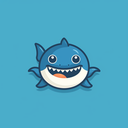

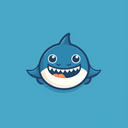

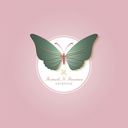

In [ ]:
index = 0
anchor, positive, negative = train_dataset[index]
display(anchor["image"])
display(positive["image"])
display(negative["image"])

In [ ]:
train_loader  = torch.utils.data.DataLoader(train_dataset,
                                            batch_size=cfg.batch_size,
                                            collate_fn=TripletLogoDataset.collate_fn
                                            )
print(f"[INFO] Number of batches in train_loader: {len(train_loader)}")

[INFO] Number of batches in train_loader: 5696


In [ ]:
batch = next(iter(train_loader))
print(batch[0].shape)

torch.Size([256, 2048, 1, 1])
